# Load libraries and functions

In [1]:
suppressPackageStartupMessages({
library(Seurat)
library(scCustomize)
library(spatula)
library(ComplexHeatmap)
    library(rcna)
    library(circlize)
    library(ggrastr)
    library(tidyverse)
    library(scico)
    library(circlize)    
    library(ggsci)
    })

In [2]:
library(ggrastr)

In [3]:
get_theme <- function(size=12, angle=45) {
    defined_theme = theme_bw(base_size=size) + theme(legend.title=element_blank(), strip.text=element_text(size=size), legend.text=element_text(size=size), axis.title.x=element_text(size=size), axis.title.y=element_text(size=size), axis.text.y=element_text(size=size), axis.text.x=element_text(size=size, angle=angle, hjust = 1, vjust=1.05), legend.position="bottom", legend.box = "horizontal")
    defined_theme
}

fig.size <- function(h, w) {
    options(repr.plot.height = h, repr.plot.width = w)
}

# Configure colors

In [4]:
heatmap_col_fun <- colorRamp2(c(-2, 0, 2), scico(3, palette = "vik"))  # "vik" is diverging

niche_cols = pal_npg("nrc")(9)
niche_cols

[1] "#E64B35FF" "#4DBBD5FF" "#00A087FF" "#3C5488FF" "#F39B7FFF" "#8491B4FF"
[7] "#91D1C2FF" "#DC0000FF" "#7E6148FF"

In [5]:
celltype_colors <- c(
    # cell groups
  "T" = "#1b7837",
  "Regulatory T" = "#238b45",
  "Proliferating T cell" = "#006d2c",
  "Immune (LowQ)" = "#ccebc5",

  # B/Plasma (purples)
  "B" = "#d0d1e6",
  "Plasma" = "#54278f",

  # Myeloid (yellows & oranges)
  "Tissue Myeloid" = "#ffffcc",
  "Monocyte" = "#ffeda0",
  "Inflammatory Myeloid" = "#feb24c",
  "cDC1" = "#fee0d2",
  "pDC" = "#fee0d2",
  "Basophil" = "#fee0d2",    
    

  # Endothelial (blues)
  "Endothelial" = "#c6dbef",

  # Kidney cells (reds & browns)
  "Podocyte" = "#fbb4ae",
  "Parietal" = "#f768a1",
  "Proximal Tubule" = "#c51b8a",
  "Thick Ascending Limb" = "#7a0177",
  "Thin Ascending Limb" = "#fdae6b",
  "Thin Descending Limb" = "#e6550d",
  "Interstitial" = "#a63603",
  "Distal Convoluted Tubule" = "#6e016b",
  "Collecting Duct-IC" = "#6e016b",
  "Collecting Duct-PC" = "#6e016b",
  "Connecting Tubule" = "#6e016b"    
)


In [6]:
celltype_colors <- c(
  # T/ILC (greens)
  "T"                   = "#a1d99b",  # medium green
  "Regulatory T"        = "#74c476",  # darker green
  "Proliferating T cell"= "#31a354",  # even darker green
  "Immune (LowQ)"       = "#e5f5e0",  # pale green

  # B/Plasma (purples)
  "B"                   = "#bcbddc",  # lavender
  "Plasma"              = "#756bb1",  # deep purple

  # Myeloid (yellows/oranges)
  "Tissue Myeloid"      = "#fff7bc",  # pale yellow
  "Monocyte"            = "#fec44f",  # golden yellow
  "Inflammatory Myeloid"= "#fe9929",  # orange
  "cDC1"                = "#ec7014",  # orange-brown
  "pDC"                 = "#cc4c02",  # dark orange
  "Basophil"            = "#993404",  # darkest orange-brown

  # Endothelial (blues)
  "Endothelial"         = "#6baed6",  # sky blue

  # Kidney cells (reds → pinks → violets)
  "Podocyte"            = "#fcbba1",  # soft pink
  "Parietal"            = "#fc9272",  # salmon
  "Proximal Tubule"     = "#fb6a4a",  # coral red
  "Thick Ascending Limb"= "#ef3b2c",  # tomato red
  "Thin Ascending Limb" = "#cb181d",  # crimson
  "Thin Descending Limb"= "#a50f15",  # dark red
  "Interstitial"        = "#67000d",  # very dark red
    
  # Duct...
  "Distal Convoluted Tubule" = "#9e9ac8",  # violet
  "Collecting Duct-IC"  = "#807dba",  # medium violet
  "Collecting Duct-PC"  = "#6a51a3",  # darker violet
  "Connecting Tubule"   = "#4a1486"   # deep purple-violet
)


# Configure arrow

In [7]:
axis <- ggh4x::guide_axis_truncated(
  trunc_lower = unit(0, "npc"),
  trunc_upper = unit(3, "cm")
)


Warning message:
“`guide_axis_truncated()` was deprecated in ggh4x 0.3.0.
ℹ Please use `ggplot2::guide_axis(cap = TRUE)` instead.”


# Load data

In [8]:
sc.niche <- readRDS("../phaseF_newpipeline/sopa_seg/sopa_baysor_tessera.rds")
lennard.subtype <- readRDS("../phaseZ_finalize_figs/250721_cells_annotated_lennard.rds")
imm.niche <- readRDS("../phaseZ_finalize_figs/250711_niches.rds")

In [9]:
niche.merge = imm.niche 
obj.merge = lennard.subtype
orig.merge = readRDS("../phaseF_newpipeline/sopa_seg/output/all_KPMP_integrate_singlet_umap_umapnn_labels_umap.rds")

In [10]:
meta = read.csv("~/shruti_meta_clean (3).csv")
input_meta = meta[,c('slide_id', 'age', 'sex', 'case_ctrl', 'ICPi',  'malignancy', 'eGFR_base')] %>% arrange(case_ctrl)

In [11]:
input_meta

slide_id,age,sex,case_ctrl,ICPi,malignancy,eGFR_base
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>
BS21-N65682A2,68,F,Case,Pembrolizumab,Urothelial,53
BS22-T41795A1,83,F,Case,Pembrolizumab,Bladder,36
BS23_49001A1,68,F,Case,Pembrolizumab,Uterine Cancer,73
BS23_52206A2,55,F,Case,Atezolizumab,Melanoma,92
BS22_12012A1,66,F,Control,Pembrolizumab,Lung adenocarcinoma,97
BS2_61615A1,79,M,Control,Pembrolizumab,Head and Neck,59
BS24-R31519A2,75,M,Control,Pembrolizumab,NSCLC,60
BS24-M35359A1,76,M,Control,Nivolumab/Retalimab,Renal Cell Carcinoma,63


## Check data

In [12]:
cells_to_keep <- colnames(orig.merge)[orig.merge$tech=='xenium']
orig.merge.xen <- subset(orig.merge, cells = cells_to_keep)


# Main cells
main_cells <- colnames(orig.merge.xen)

# Assay cells
assay_cells <- colnames(orig.merge.xen@assays$RNA)  # or whichever assay you're using

# PCA cells
pca_cells <- rownames(orig.merge.xen@reductions$pca@cell.embeddings)

# Graph cells
graph_cells <- colnames(orig.merge.xen[['humap_fgraph']])  # adapt if using another graph

# Active identity names
ident_cells <- names(Idents(orig.merge.xen))

# Check mismatches
length(setdiff(assay_cells, main_cells))
length(setdiff(pca_cells, main_cells))
length(setdiff(graph_cells, main_cells))
length(setdiff(ident_cells, main_cells))

[1] 0

[1] 0

[1] 0

[1] 0

## Clean meta data in Seurat object

In [13]:
orig.merge.xen@meta.data  = orig.merge.xen@meta.data %>% mutate(sample_id=str_extract(sample, "__(BS\\d*[_-].*)__2024", group=1))
orig.merge.xen@meta.data  = orig.merge.xen@meta.data %>% mutate(case_ctrl=str_trim(input_meta[match(sample_id, input_meta$slide_id), 'case_ctrl']))
orig.merge.xen@meta.data$case_ctrl_num = as.numeric(factor(str_trim(orig.merge.xen@meta.data$case_ctrl), levels=c("Control", "Case")))
obj.merge@meta.data  = obj.merge@meta.data %>% mutate(sample_id=str_extract(sample, "__(BS\\d*[_-].*)__2024", group=1))
obj.merge@meta.data  = obj.merge@meta.data %>% mutate(case_ctrl=str_trim(input_meta[match(sample_id, input_meta$slide_id), 'case_ctrl']))
obj.merge@meta.data$case_ctrl_num = as.numeric(factor(str_trim(obj.merge@meta.data$case_ctrl), levels=c("Control", "Case")))

In [14]:
obj.merge@meta.data$cell_label = gsub(" Cell", "", obj.merge@meta.data$lennard_label)
obj.merge@meta.data = obj.merge@meta.data %>% mutate(cell_label = ifelse(cell_label=='Immune', 'Immune (LowQ)', cell_label))

In [15]:
orig.baysor <- readRDS("../phaseF_newpipeline/sopa_seg/comb_h5ad/kidney_orig_seg_merged.rds")
orig.baysor@meta.data <- orig.baysor@meta.data%>%unite("uniq_id", c(sample, cell_id), remove=F)
lennard.subtype@meta.data <- lennard.subtype@meta.data%>%unite("uniq_id", c(sample, cell_id), remove=F)
xy <- Embeddings(orig.baysor, 'spatial')[match(lennard.subtype@meta.data$uniq_id, orig.baysor@meta.data$uniq_id),]
rm(orig.baysor)

# Sample info and desensitive patient id

In [16]:
meta = read.csv("~/shruti_meta_clean (3).csv")
input_meta = meta[,c('slide_id', 'age', 'sex', 'case_ctrl', 'ICPi',  'malignancy', 'eGFR_base')] %>% arrange(case_ctrl)
#tile_obj$condition = str_trim(meta[match(str_extract(as.character(obj.merge$sample_id), "(.*)__", group=1), meta$slide_id), 'case_ctrl'])

test = obj.merge@meta.data %>% filter(tech=='xenium') %>% janitor::clean_names()
test$condition = str_trim(meta[match(str_extract(as.character(subset(obj.merge, subset=tech=='xenium')$orig.ident), "__(BS.*A[1,2])__(2.+)", group=1), meta$slide_id), 'case_ctrl'])

sample_ids = test %>% filter(tech=='xenium') %>% count(sample_ids, lennard_label) %>% group_by(sample_ids) %>%
    mutate(ratio = n/sum(n)) %>% select(-n) %>% pivot_wider(names_from=lennard_label, values_from=ratio, values_fill = 0) %>% ungroup() %>% select(sample_ids) %>% pull()
sample_mat = as.matrix(test %>% filter(tech=='xenium') %>% count(sample_ids, lennard_label) %>% group_by(sample_ids) %>%
    mutate(ratio = n/sum(n)) %>% select(-n) %>% pivot_wider(names_from=lennard_label, values_from=ratio, values_fill = 0) %>% ungroup() %>% select(-sample_ids))
rownames(sample_mat) = str_extract(as.character(sample_ids), "__(BS.*A[1,2])__(2.+)", group=1)

my_sample_col <- data.frame(sample = str_trim(meta$case_ctrl))
row.names(my_sample_col) <- meta$slide_id

my_sample_col <- my_sample_col %>% arrange(sample)
## my_sample_col = my_sample_col[rownames(sample_mat), ,drop=F]

my_sample_col = my_sample_col %>%
    mutate(group=case_when(
               sample=="Case" ~ "ICI-AIN",
               sample=="Control" ~ "ICI-ATN")) %>%
    mutate(group_simple = case_when(
               sample=="Case" ~ "AIN",
               sample=="Control" ~ "ATN")) %>%
    mutate(patient=rep(seq(1, 4), 2))  %>%
    unite("patient_id", c(group_simple, patient), remove=F)

In [17]:
my_sample_col

,sample,group,patient_id,group_simple,patient
,<chr>,<chr>,<chr>,<chr>,<int>
BS21-N65682A2,Case,ICI-AIN,AIN_1,AIN,1
BS22-T41795A1,Case,ICI-AIN,AIN_2,AIN,2
BS23_49001A1,Case,ICI-AIN,AIN_3,AIN,3
BS23_52206A2,Case,ICI-AIN,AIN_4,AIN,4
BS22_12012A1,Control,ICI-ATN,ATN_1,ATN,1
BS2_61615A1,Control,ICI-ATN,ATN_2,ATN,2
BS24-R31519A2,Control,ICI-ATN,ATN_3,ATN,3
BS24-M35359A1,Control,ICI-ATN,ATN_4,ATN,4


# fig 1b

In [18]:
markers = c("CD8A", "CD2", "ZAP70", "CTLA4", "FOXP3", "TIGIT", "CD3E", "MKI67", "TUBB", "XBP1", "CD38", "FCRL5", "MS4A1", "CD19", "CD79A", "CD163", "MRC1", "F13A1", "CD14", "CIITA", "FCN1", "CXCL9", "CXCL10", "MMP9", "WDFY4", "CLEC9A", "IRF8", "GZMB", "LILRA4", "IL3RA", "KIT", "HDC",  "PECAM1", "PLVAP", "PDGFRB", "PODXL", "FGF1", "NES", "SHANK3",  "ITGB3", "CFH", "BMP7", "TNC", "AEBP1", "LRP2", "CUBN", "PAH", "ITGB6", "CA12", "MUC1",  "EPCAM", "PROM1", "PAX8", "HSD11B2", "KCNJ10", "SERPINA5", "UMOD", "CASR", "SCNN1A", "SLC4A1", "DMRT2", "CLNK", "SCNN1G", "GATA3", "PFKFB3", "PKHD1", "CALB1", "KCNJ1")

In [19]:
baysor = readRDS("../phaseF_newpipeline/sopa_seg/group_all_qc/all_kidneycells_orig_seg_adddbl.rds")
orig = readRDS("../data/miles/shapes_seur_kidney_v5.rds")$seur

In [20]:
dim(baysor)

[1]   4959 408821

In [21]:
dim(orig)

[1]   5001 235966

In [22]:
summary(orig$cell_area)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  10.02   40.51   58.93   71.02   88.05  299.93 

In [23]:
summary(orig$nCount_RNA)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   11.0   110.0   208.0   289.8   379.0  1998.0 

In [24]:
summary(orig$nFeature_RNA)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    8.0   100.0   180.0   224.5   304.0  1158.0 

In [25]:
summary(baysor$nCount_RNA)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   20.0    68.0   138.0   224.8   274.0  4577.0 

In [26]:
summary(baysor$nFeature_RNA)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   20.0    62.0   119.0   171.1   223.0  1690.0 

In [27]:
summary(baysor$area)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  10.00   26.17   41.97   54.02   67.19 2114.90 

In [28]:
orig@meta.data$sample = gsub("_orig_seg.h5ad", "", basename(as.character(orig@meta.data$sample)))
baysor@meta.data$sample = gsub("_orig_seg.h5ad", "", basename(as.character(baysor@meta.data$sample)))

In [29]:
orig.sub = subset(orig, subset = nFeature_RNA >= 20 & nCount_RNA >= 20)

In [30]:
dim(orig.sub)

[1]   5001 233365

In [31]:
dim(orig)

[1]   5001 235966

# Fig1a

In [32]:
orig.cnt = orig.sub@meta.data %>% count(sample)
baysor.cnt = baysor@meta.data %>% count(sample)
joint.cnt = baysor.cnt %>% left_join(orig.cnt, suffix = c(".baysor", ".10x"), by='sample') %>% 
    pivot_longer(cols=c(n.baysor, n.10x)) 
joint.cnt = joint.cnt %>% mutate(sample=str_extract(sample, "_(BS\\d*[_-].*A\\d)_", group = 1))

In [33]:
joint.cnt = joint.cnt %>% left_join(my_sample_col %>% rownames_to_column() %>% select(-"sample") %>% rename(sample=rowname), by='sample') %>% 
  mutate(name = case_when(
      name == 'n.baysor' ~ "baysor",
      name == 'n.10x' ~ '10x'
      )) %>% mutate(patient_id = case_when(
      grepl("AIN", patient_id) ~ gsub("AIN", "ICI-AIN", patient_id),
      grepl("ATN", patient_id) ~ gsub("ATN", "ICI-ATN", patient_id),      
  ))

In [34]:
fig.size(8, 9)
p1 = joint.cnt |> 
    ggplot(aes(x=patient_id, y=value, fill=name)) + geom_bar(stat='identity', position='dodge') + scale_fill_nejm() + get_theme(size=20) + ylab("#Segmented Cells") + xlab("") + theme(legend.position='none')

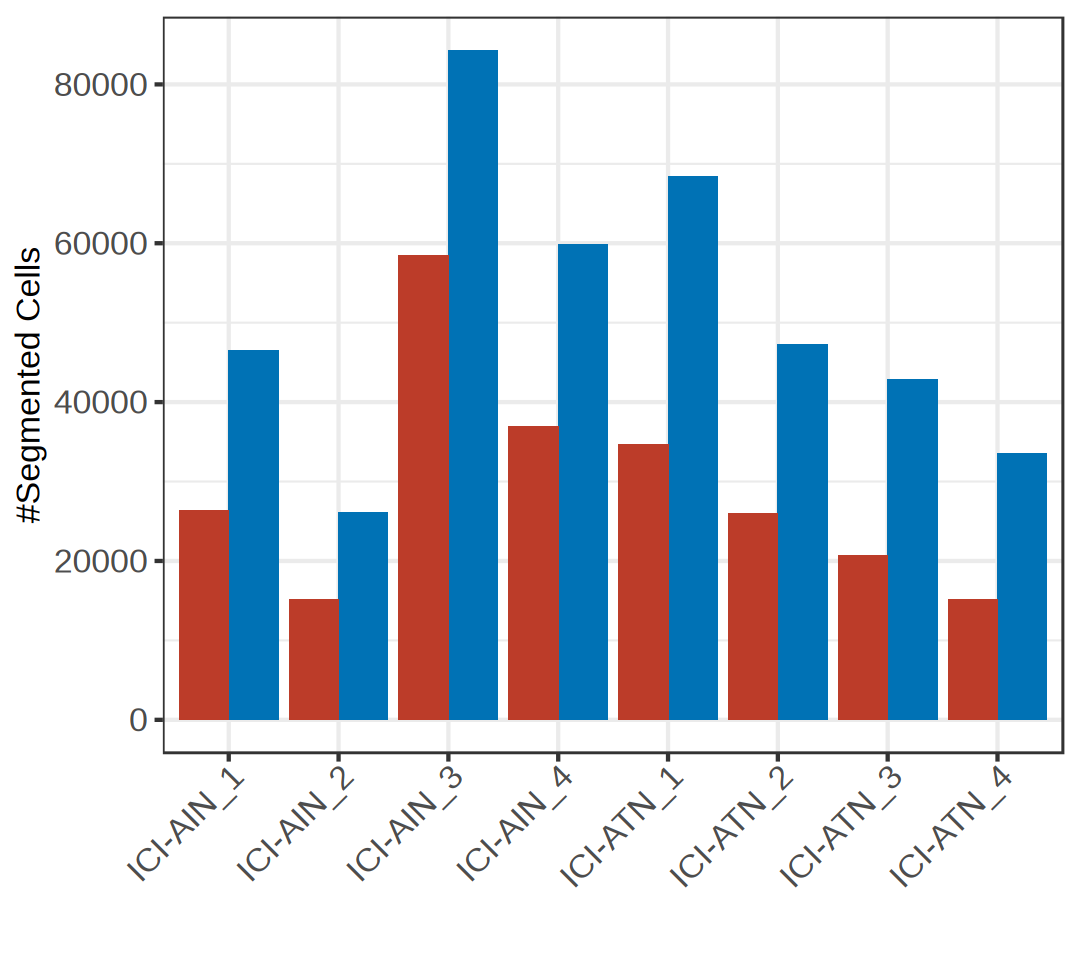

In [35]:
p1

In [36]:
mols = colSums(orig.sub[['RNA']]$counts)
mols_baysor = colSums(baysor[['RNA']]$counts)

In [37]:
mols_num = colSums(orig.sub[['RNA']]$counts > 0)
mols_num_baysor = colSums(baysor[['RNA']]$counts > 0)

In [38]:
orig.sub$mols_num = mols_num
baysor$mols_num_baysor = mols_num_baysor
orig.sub$mols_counts = mols
baysor$mols_counts_baysor = mols_baysor

In [39]:
my_sample_col

,sample,group,patient_id,group_simple,patient
,<chr>,<chr>,<chr>,<chr>,<int>
BS21-N65682A2,Case,ICI-AIN,AIN_1,AIN,1
BS22-T41795A1,Case,ICI-AIN,AIN_2,AIN,2
BS23_49001A1,Case,ICI-AIN,AIN_3,AIN,3
BS23_52206A2,Case,ICI-AIN,AIN_4,AIN,4
BS22_12012A1,Control,ICI-ATN,ATN_1,ATN,1
BS2_61615A1,Control,ICI-ATN,ATN_2,ATN,2
BS24-R31519A2,Control,ICI-ATN,ATN_3,ATN,3
BS24-M35359A1,Control,ICI-ATN,ATN_4,ATN,4


In [40]:
orig.cnt = orig.sub@meta.data %>% group_by(sample) %>% summarise(feature_counts=sum(mols_counts))
baysor.cnt = baysor@meta.data %>% group_by(sample) %>% summarise(feature_counts=sum(mols_counts_baysor))

In [41]:
orig.cnt

sample,feature_counts
<chr>,<dbl>
output-XETG00150__0018462__BS22_12012A1__20240803__183643,9387414
output-XETG00150__0018462__BS23_49001A1__20240803__183643,9998431
output-XETG00150__0018462__BS23_52206A2__20240803__183643,15574220
output-XETG00150__0018462__BS2_61615A1__20240803__183643,5179678
output-XETG00392__0045655__BS21-N65682A2__20241025__201009,6234033
output-XETG00392__0045655__BS22-T41795A1__20241025__201009,3899374
output-XETG00392__0045655__BS24-M35359A1__20241025__201009,7692798
output-XETG00392__0045655__BS24-R31519A2__20241025__201009,10378594


In [42]:
joint.cnt = baysor.cnt %>% left_join(orig.cnt, suffix = c(".baysor", ".10x"), by='sample')
joint.cnt = joint.cnt %>% pivot_longer(cols=c(feature_counts.baysor, feature_counts.10x))
joint.cnt = joint.cnt %>% mutate(sample=str_extract(sample, "_(BS\\d*[_-].*A\\d)_", group = 1))

In [43]:
joint.cnt

sample,name,value
<chr>,<chr>,<dbl>
BS22_12012A1,feature_counts.baysor,13192156
BS22_12012A1,feature_counts.10x,9387414
BS23_49001A1,feature_counts.baysor,12123827
BS23_49001A1,feature_counts.10x,9998431
BS23_52206A2,feature_counts.baysor,19996997
BS23_52206A2,feature_counts.10x,15574220
BS2_61615A1,feature_counts.baysor,6886485
BS2_61615A1,feature_counts.10x,5179678
BS21-N65682A2,feature_counts.baysor,7877419


In [44]:
joint.cnt = joint.cnt %>% left_join(my_sample_col %>% rownames_to_column() %>% select(-"sample") %>% rename(sample=rowname), by='sample') %>% 
  mutate(name = case_when(
      name == 'feature_counts.baysor' ~ "baysor",
      name == 'feature_counts.10x' ~ '10x'
      )) %>% mutate(patient_id = case_when(
      grepl("AIN", patient_id) ~ gsub("AIN", "ICI-AIN", patient_id),
      grepl("ATN", patient_id) ~ gsub("ATN", "ICI-ATN", patient_id),      
  ))

In [45]:
joint.cnt

sample,name,value,group,patient_id,group_simple,patient
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>
BS22_12012A1,baysor,13192156,ICI-ATN,ICI-ATN_1,ATN,1
BS22_12012A1,10x,9387414,ICI-ATN,ICI-ATN_1,ATN,1
BS23_49001A1,baysor,12123827,ICI-AIN,ICI-AIN_3,AIN,3
BS23_49001A1,10x,9998431,ICI-AIN,ICI-AIN_3,AIN,3
BS23_52206A2,baysor,19996997,ICI-AIN,ICI-AIN_4,AIN,4
BS23_52206A2,10x,15574220,ICI-AIN,ICI-AIN_4,AIN,4
BS2_61615A1,baysor,6886485,ICI-ATN,ICI-ATN_2,ATN,2
BS2_61615A1,10x,5179678,ICI-ATN,ICI-ATN_2,ATN,2
BS21-N65682A2,baysor,7877419,ICI-AIN,ICI-AIN_1,AIN,1


In [46]:
head(joint.cnt)

sample,name,value,group,patient_id,group_simple,patient
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>
BS22_12012A1,baysor,13192156,ICI-ATN,ICI-ATN_1,ATN,1
BS22_12012A1,10x,9387414,ICI-ATN,ICI-ATN_1,ATN,1
BS23_49001A1,baysor,12123827,ICI-AIN,ICI-AIN_3,AIN,3
BS23_49001A1,10x,9998431,ICI-AIN,ICI-AIN_3,AIN,3
BS23_52206A2,baysor,19996997,ICI-AIN,ICI-AIN_4,AIN,4
BS23_52206A2,10x,15574220,ICI-AIN,ICI-AIN_4,AIN,4


In [47]:
p2 = joint.cnt |> 
    ggplot(aes(x=patient_id, y=value, fill=name)) + geom_bar(stat='identity', position='dodge') + scale_fill_nejm() + get_theme(size=20) + ylab("#Transcripts Counts") + xlab("") + theme(legend.position='none')

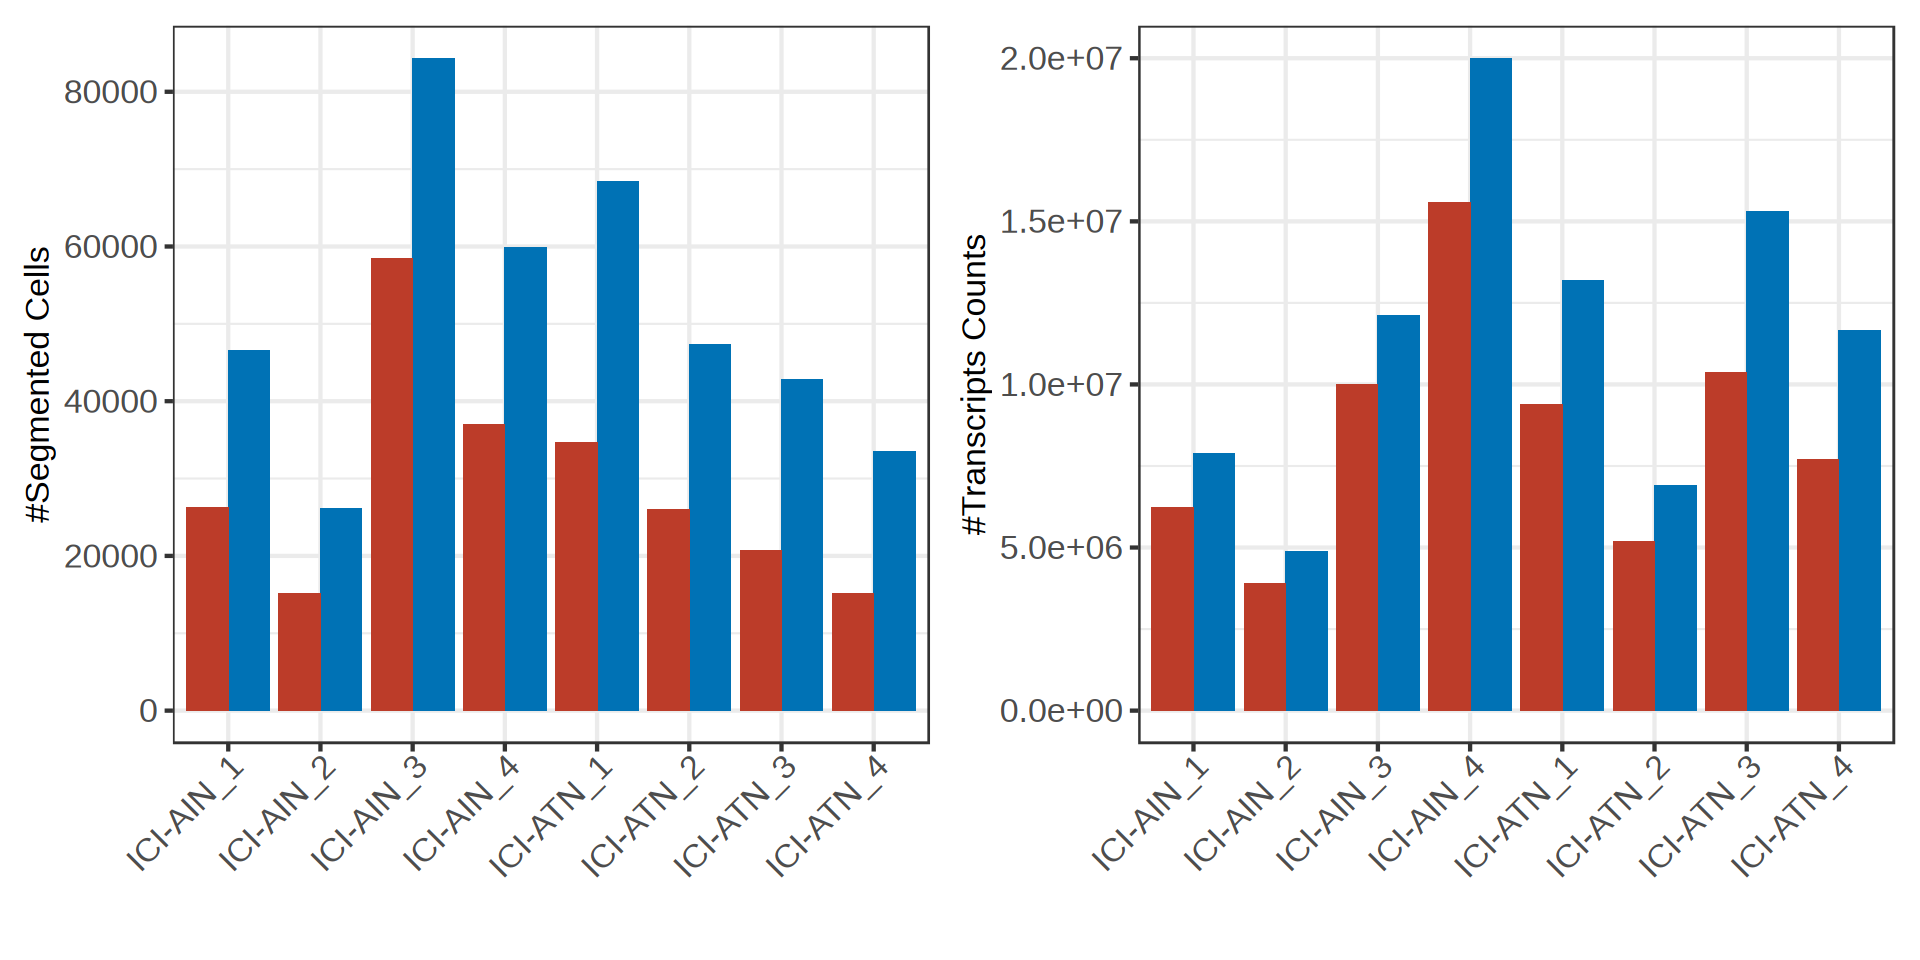

In [48]:
fig.size(8, 16)

p1 | p2

# Fig.1b QC of xenium based on SOPA

In [49]:
obj.merge@meta.data = obj.merge@meta.data %>% mutate(cell_label = factor(cell_label, levels=names(celltype_colors)))

In [50]:
p3 = VlnPlot_scCustom(obj.merge, features=c("nCount_RNA"), group.by="cell_label", pt.size = 0) + NoLegend() + scale_fill_manual(values=celltype_colors)
p4 = VlnPlot_scCustom(obj.merge, features=c("nFeature_RNA"), group.by="cell_label", pt.size = 0) + NoLegend() + scale_fill_manual(values=celltype_colors) 

Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


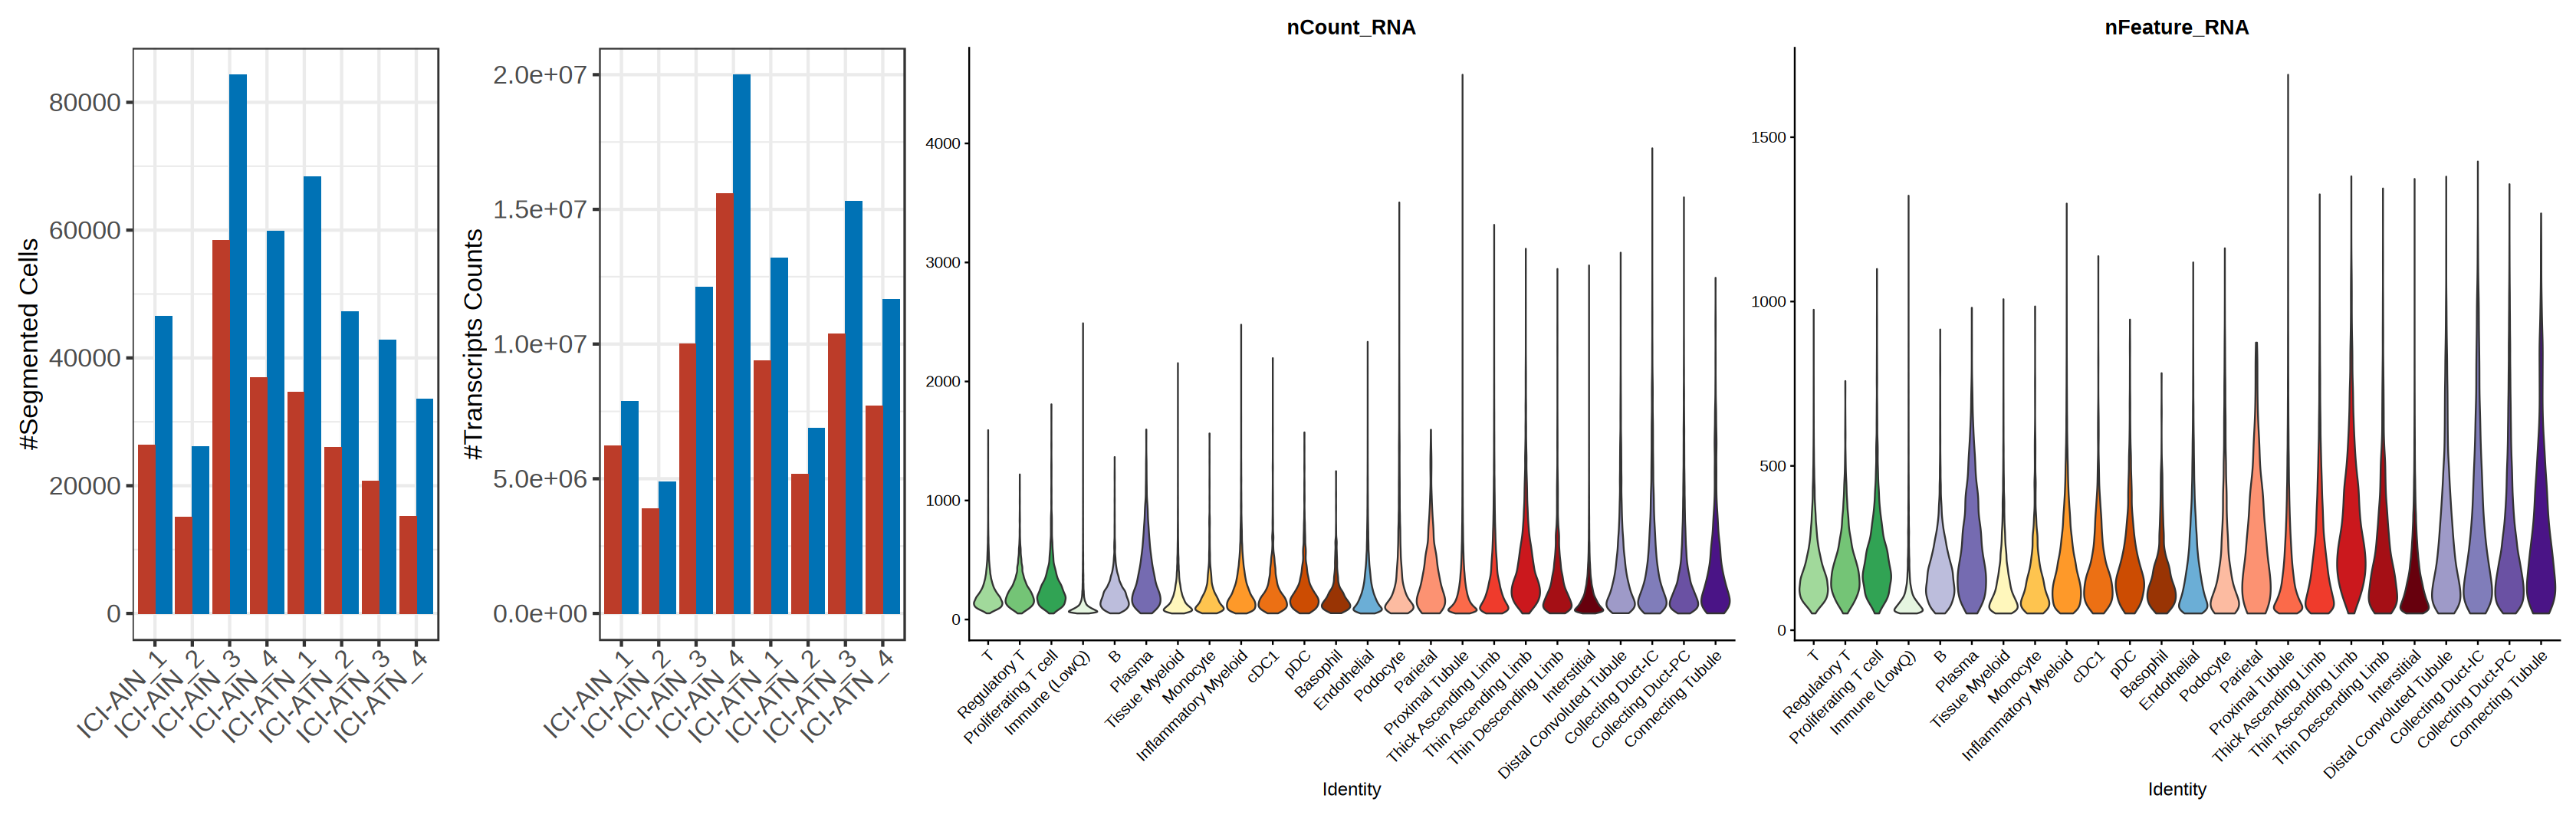

In [51]:
library(patchwork)
fig.size(9, 28)
p1 + p2 + p3 + p4 + plot_layout(ncol=4, widths = c(1, 1, 2.5, 2.5), guides='collect') # & theme(legend.position='bottom')

# Fig.1c

In [52]:
table(orig.merge$tech)


    sc xenium 
225177 332341 

In [74]:
p11=DimPlot_scCustom(subset(orig.merge, subset = tech=='sc'), raster = TRUE, label=T, repel=T, label.size=6,
    raster.dpi = c(300, 300), group.by="fine_ids", seed=99) +ggplot2::theme(legend.position = "right",         
                                                                             axis.line = element_line(arrow = arrow(type = "closed", length = unit(10, 'pt'))))+
    scale_x_continuous(breaks = NULL) +
    scale_y_continuous(breaks = NULL) + NoLegend()+ggtitle("KPMP scRNA-seq")+xlab("")+ylab("") #+scale_color_manual(values=celltype_colors)

p12=DimPlot_scCustom(subset(orig.merge, subset = tech=='xenium'), raster = TRUE,        # enable rasterization
  raster.dpi = c(300, 300),  group.by="fine_ids", seed=99) +ggplot2::theme(legend.position = "none") + ggtitle("Xenium 8 patients")+scale_x_continuous(breaks = NULL)+ scale_y_continuous(breaks = NULL)+xlab("")+ylab("") 


In [1]:
#p11 | p12

In [55]:
head(sample_mat)

,B Cell,Basophil,Collecting Duct-IC,Collecting Duct-PC,Connecting Tubule,Distal Convoluted Tubule,Endothelial Cell,Immune Cell,Inflammatory Myeloid Cell,Interstitial Cell,⋯,Proliferating T cell,Proximal Tubule,Regulatory T Cell,T Cell,Thick Ascending Limb,Thin Ascending Limb,Thin Descending Limb,Tissue Myeloid Cell,cDC1,pDC
BS22_12012A1,0.0029817864,0.001367443,0.032533759,0.05617914,0.004596129,0.014548079,0.09479042,0.01462405,0.03441399,0.19119518,⋯,0.0030577555,0.3637210,0.0038934154,0.02772871,0.07055628,0.012420945,0.006685279,0.03686400,0.001918219,0.0016903120
BS23_49001A1,0.0115354077,0.003460622,0.009767644,0.05878564,0.002352025,0.008479274,0.04067355,0.09782625,0.09721203,0.06200656,⋯,0.0227412323,0.1839074,0.0179772588,0.17345059,0.06104777,0.011070995,0.005707780,0.09497985,0.011700199,0.0093931177
BS23_52206A2,0.0033898305,0.001334856,0.001984719,0.02567841,0.001159217,0.006885044,0.10069377,0.05861070,0.10749100,0.16724335,⋯,0.0044787916,0.1589708,0.0129094582,0.09342232,0.08736278,0.019601300,0.017265303,0.07808905,0.003811364,0.0040396944
BS2_61615A1,0.0008613009,0.001306801,0.031600832,0.07389367,0.006474606,0.021740422,0.09774280,0.01517672,0.02631423,0.17793288,⋯,0.0009207009,0.3819127,0.0005049005,0.01378081,0.08452628,0.014731215,0.008375408,0.02307692,0.001633502,0.0003861004
BS21-N65682A2,0.0343178775,0.005191399,0.003552010,0.04868985,0.002868931,0.013524960,0.06505642,0.04822536,0.08511162,0.14948496,⋯,0.0058471543,0.2633405,0.0181425722,0.08869095,0.04210498,0.007896391,0.004289735,0.06732424,0.006748818,0.0074045739
BS22-T41795A1,0.0121876618,0.003246906,0.002682227,0.05439744,0.001976378,0.012422945,0.10738318,0.04950355,0.09637194,0.18610889,⋯,0.0096466049,0.1445579,0.0105406804,0.07806691,0.11453579,0.020469625,0.011152416,0.06616159,0.006493812,0.0046115477


In [56]:
sample_mat = sample_mat[rownames(my_sample_col),]
rownames(sample_mat) = my_sample_col$patient_id

In [57]:
sample_mat <- scale(sample_mat)

In [58]:
head(sample_mat)

,B Cell,Basophil,Collecting Duct-IC,Collecting Duct-PC,Connecting Tubule,Distal Convoluted Tubule,Endothelial Cell,Immune Cell,Inflammatory Myeloid Cell,Interstitial Cell,⋯,Proliferating T cell,Proximal Tubule,Regulatory T Cell,T Cell,Thick Ascending Limb,Thin Ascending Limb,Thin Descending Limb,Tissue Myeloid Cell,cDC1,pDC
AIN_1,2.2664994,1.9603866,-0.8705105,-0.48937012,-0.4859245,-0.3747272,-0.9221048,0.3043159,0.6157396,-0.03722059,⋯,-0.01822159,-0.2285116,1.3070361,0.4340841,-1.2372483,-1.0838581,-0.94229667,0.5569417,0.6526863,1.1166609
AIN_2,0.3207481,0.6004512,-0.9102264,-0.19723473,-0.8519459,-0.5102889,0.6510032,0.3461143,0.9081514,0.84203255,⋯,0.49141221,-1.2448680,0.2921215,0.2415075,1.8516300,1.5338294,0.69645553,0.5177954,0.5860780,0.3090037
AIN_3,0.2634001,0.7499196,-0.5866927,0.02736944,-0.6978992,-0.9954101,-1.8283140,1.9263257,0.9299672,-2.13736810,⋯,2.24784110,-0.9081768,1.2849654,1.9704800,-0.4294153,-0.4229205,-0.60367914,1.4881026,1.9460012,1.6916865
AIN_4,-0.4527821,-0.7367950,-0.9420760,-1.66718154,-1.1870502,-1.1915204,0.4023860,0.6439290,1.1968950,0.38911594,⋯,-0.20176493,-1.1215453,0.6083726,0.5198474,0.6928123,1.3530482,2.15616270,0.9193914,-0.1145851,0.1436414
ATN_1,-0.4886585,-0.7140037,0.4528517,-0.10604096,0.2223712,-0.2488706,0.1829831,-0.7944882,-0.7007935,0.96414235,⋯,-0.39237355,0.6303876,-0.5953427,-0.6709481,-0.0239162,-0.1418675,-0.37026028,-0.4686511,-0.6090799,-0.5357276
ATN_2,-0.6750976,-0.7564155,0.4102525,0.80065489,0.9927038,0.6358781,0.2927106,-0.7764153,-0.9111310,0.64574604,⋯,-0.67902427,0.7860439,-1.0477372,-0.9237748,0.5718473,0.3391197,0.03332876,-0.9328602,-0.6834490,-0.9128655


In [59]:
my_sample_col = my_sample_col %>% rownames_to_column()
my_sample_col = my_sample_col %>% column_to_rownames(var='patient_id')

In [60]:
col_fun <- colorRamp2(c(-1, 0, 1), c("blue", "white", "red"))
ht_opt("heatmap_row_names_gp" = gpar(fontsize = 15))
ha1 = rowAnnotation(samples = my_sample_col$group,
                    col=list(samples=c('ICI-AIN'='gray', 'ICI-ATN'='black')),
                    annotation_name_gp = gpar(fontsize = 15),
                    annotation_legend_param = list(
                    samples = list(title_gp = gpar(fontsize = 15), labels_gp = gpar(fontsize = 5), direction = "horizontal")))

colnames(sample_mat)[colnames(sample_mat)=='Immune Cell'] = 'Immune (LowQ)'
colnames(sample_mat) = gsub(" Cell", "", colnames(sample_mat))
sample_mat = sample_mat[, names(celltype_colors)]

In [62]:
# # Desired cell size
# cell_width <- unit(2.5, "mm")   # width per column
# cell_height <- unit(3.5, "mm")   # height per row
# # Main heatmap
# ht2 <- Heatmap(
#   t(sample_mat),
#   name = "Expression",
#   col = col_fun,
# #  width = cell_width * ncol(sample_mat),
# #  height = cell_height * nrow(sample_mat),
#   column_names_gp = gpar(fontsize = 15),
#   heatmap_legend_param = list(
#     title_gp = gpar(fontsize = 15),
#     labels_gp = gpar(fontsize = 15),
#     direction = "horizontal"
#   ),cluster_columns = FALSE,
#   column_names_side = "top",
#   right_annotation = ha1)
# ht_plot <- wrap_elements(full=grid.grabExpr(draw(ht2,
#                               merge_legend = TRUE, heatmap_legend_side = "bottom",
#                               annotation_legend_list = NULL)))

In [63]:
# ht_plot

# Supp Fig. 1e

In [64]:
table(obj.merge$sample_id)


  BS2_61615A1 BS21-N65682A2  BS22_12012A1 BS22-T41795A1  BS23_49001A1 
        33670         36599         52653         21251         66751 
 BS23_52206A2 BS24-M35359A1 BS24-R31519A2 
        56935         27870         36612 

In [65]:
obj.merge@meta.data$condition = factor(str_trim(orig.merge.xen@meta.data$case_ctrl), levels=c("Control", "Case"))

In [66]:
head(obj.merge@meta.data[, c("sample_id", "cell_label", "case_ctrl")])

,sample_id,cell_label,case_ctrl
,<chr>,<fct>,<chr>
3,BS21-N65682A2,Inflammatory Myeloid,Case
4,BS21-N65682A2,Proximal Tubule,Case
5,BS21-N65682A2,Proximal Tubule,Case
6,BS21-N65682A2,Endothelial,Case
7,BS21-N65682A2,Inflammatory Myeloid,Case
9,BS21-N65682A2,Immune (LowQ),Case


In [67]:
# library(sccomp)

# res = obj.merge %>% sccomp_estimate(,
#       formula_composition = ~ condition,
#       sample = "sample_id", cell_group = "lennard_label",
#       cores = 1, verbose=T
#     )

# #res = res |>  sccomp_test()

In [68]:
p2e=FeaturePlot_scCustom(subset(orig.merge, subset = tech=='xenium'), 
                         raster = TRUE, features=markers[seq(1, length(markers), 2)],
    raster.dpi = c(150, 150)) #+scale_x_continuous(breaks = NULL)+ scale_y_continuous(breaks = NULL)+xlab("")+ylab("") 


NOTE: FeaturePlot_scCustom uses a specified `na_cutoff` when plotting to
color cells with no expression as background color separate from color scale.
Please ensure `na_cutoff` value is appropriate for feature being plotted.
Default setting is appropriate for use when plotting from 'RNA' assay.
When `na_cutoff` not appropriate (e.g., module scores) set to NULL to
plot all cells in gradient color palette.

-----This message will be shown once per session.-----


In [2]:
suppfig1e = p2e
#suppfig1e

ERROR: Error: object 'p2e' not found


In [70]:
ggsave("SuppFig2.pdf", width=24, height=32)

In [71]:
getwd()

[1] "/data/wei/qq06/xenium/phaseZ2_refactor_figs"

# Assemble figures

Warning message:
“ggrepel: 19 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


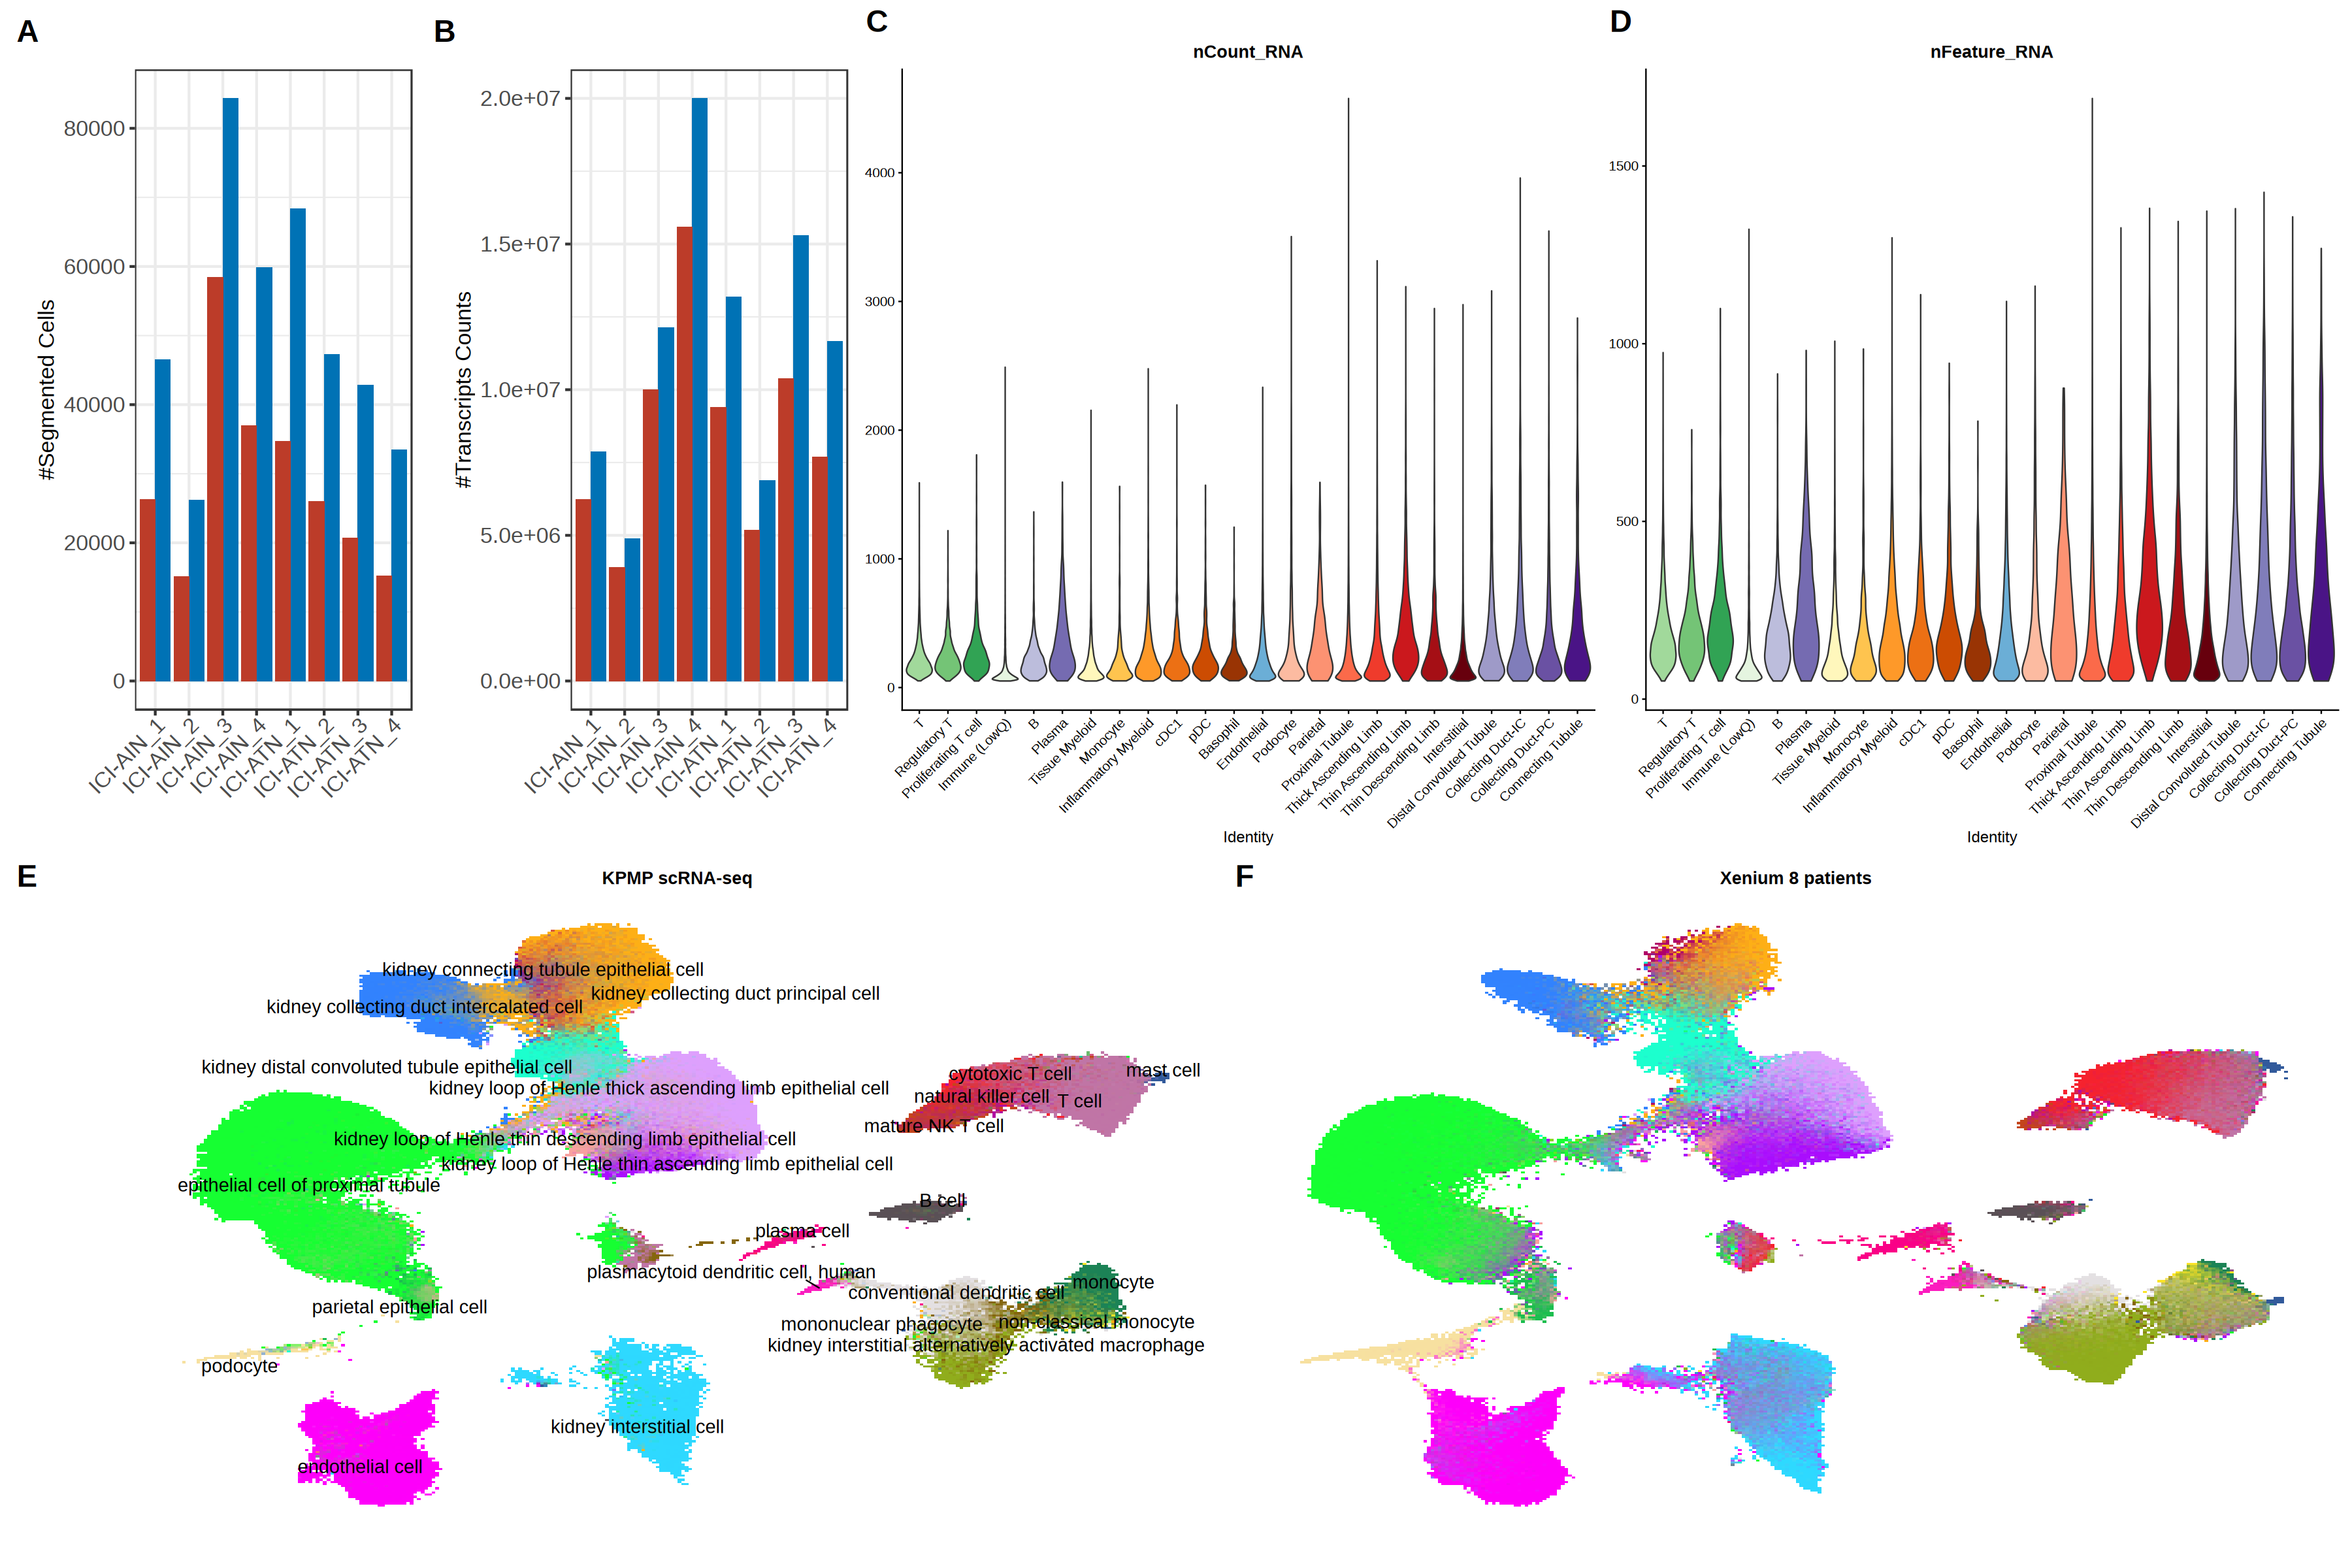

In [77]:
library(patchwork)
fig.size(20, 30)
(p1 + p2 + p3 + p4 + plot_layout(ncol=4, widths = c(1, 1, 2.5, 2.5))) / (p11 + p12 + plot_layout(ncol=2, widths = c(2.5, 2.5))) + plot_layout(nrow=2) +
 plot_annotation(
    tag_levels = list(c("A", "B", "C", "D", "E", "F")), 
 ) &  theme(plot.tag = element_text(face = "bold", size = 28))

In [79]:
ggsave("SuppFig1.pdf", width=22, height=18)